In [59]:
# ============================================================
# STEP 17 — SELECT SEGMENTATION FEATURES
# ============================================================

# Use RFM features for segmentation
segment_features = rfm[
    ['Recency', 'Frequency', 'Monetary']
]

In [60]:
# ============================================================
# STEP 18 — SCALE SEGMENTATION FEATURES
# ============================================================

# KMeans works better on scaled data

scaler = StandardScaler()

segment_scaled = scaler.fit_transform(
    segment_features
)

In [61]:
# ============================================================
# STEP 19 — ELBOW METHOD
# ============================================================

# Find best number of clusters

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(segment_scaled)

    inertia.append(kmeans.inertia_)

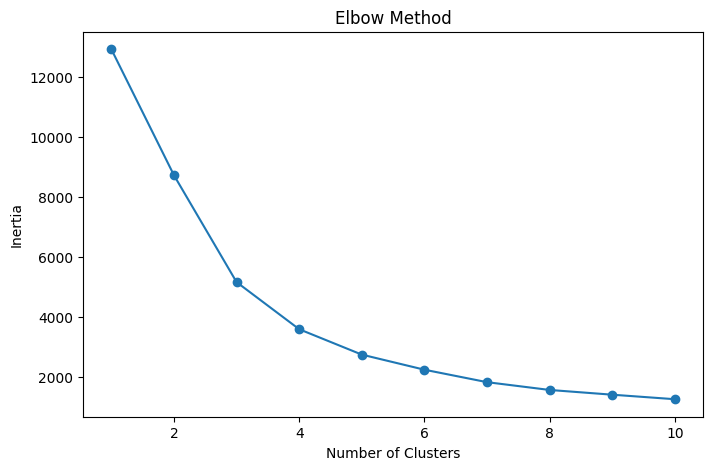

In [62]:
# ============================================================
# STEP 20 — PLOT ELBOW CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [63]:
# ============================================================
# STEP 21 — TRAIN FINAL KMEANS MODEL
# ============================================================

# Create final KMeans model
# Assume best cluster count = 4

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Predict customer clusters
rfm['Cluster'] = kmeans.fit_predict(
    segment_scaled
)

In [64]:
# ============================================================
# STEP 22 — CHECK CLUSTER DISTRIBUTION
# ============================================================

# Count customers in each cluster
print(
    rfm['Cluster'].value_counts()
)

Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64


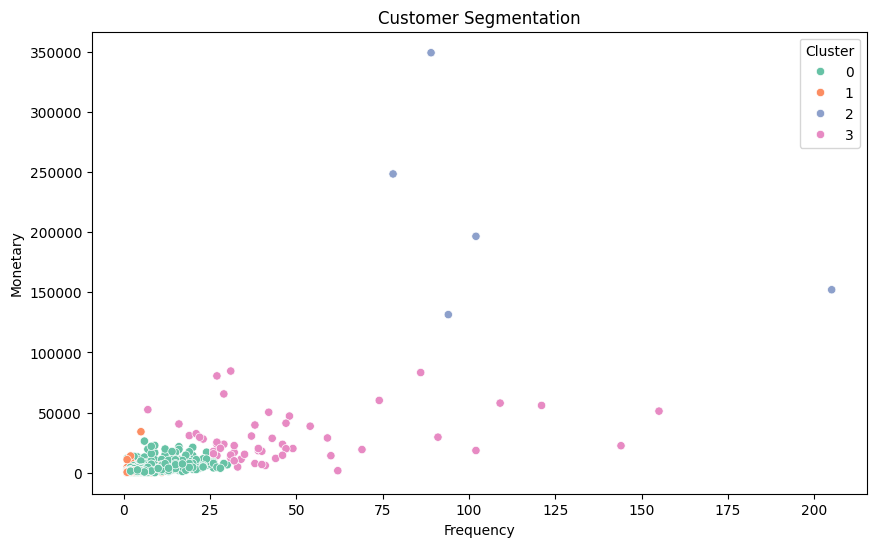

In [65]:
# ============================================================
# STEP 23 — VISUALIZE CUSTOMER SEGMENTS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segmentation')

plt.show()

In [66]:
# ============================================================
# STEP 24 — SAVE FORECAST RESULTS
# ============================================================

forecast.to_csv(
    'sales_forecast.csv',
    index=False
)

In [67]:
# ============================================================
# STEP 25 — SAVE CUSTOMER SEGMENTS
# ============================================================

rfm.to_csv(
    'customer_segments.csv',
    index=False
)

In [68]:
Phase 3:Advanced Machine Learning & Production Pipeline

SyntaxError: invalid syntax (1430704090.py, line 1)

In [69]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

In [70]:
# ============================================================
# STEP 2 — PREPARE DAILY SALES DATA
# ============================================================

# Convert InvoiceDate into datetime

daily_sales['invoicedate'] = pd.to_datetime(
    daily_sales['invoicedate']
)

# Create date-based features

daily_sales['Year'] = (
    daily_sales['invoicedate'].dt.year
)


daily_sales['Month'] = (
    daily_sales['invoicedate'].dt.month
)


daily_sales['Day'] = (
    daily_sales['invoicedate'].dt.day
)


daily_sales['Weekday'] = (
    daily_sales['invoicedate'].dt.weekday
)

In [71]:
# ============================================================
# STEP 3 — CREATE LAG FEATURES
# ============================================================

# Previous day sales

daily_sales['lag_1'] = (
    daily_sales['TotalSales'].shift(1)
)

# Previous week sales

daily_sales['lag_7'] = (
    daily_sales['TotalSales'].shift(7)
)

# Rolling average

daily_sales['rolling_mean_7'] = (
    daily_sales['TotalSales']
    .rolling(7)
    .mean()
)

In [72]:
# ============================================================
# STEP 4 — REMOVE NULL VALUES
# ============================================================

# Lag and rolling operations create null values

daily_sales.dropna(inplace=True)

In [73]:
# ============================================================
# STEP 5 — SELECT FEATURES AND TARGET
# ============================================================

X = daily_sales[
    [
        'Year',
        'Month',
        'Day',
        'Weekday',
        'lag_1',
        'lag_7',
        'rolling_mean_7'
    ]
]


y = daily_sales['TotalSales']

In [74]:
# ============================================================
# STEP 6 — TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )
)

In [75]:
# ============================================================
# STEP 7 — TRAIN XGBOOST MODEL
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [76]:
predictions = xgb_model.predict(X_test)

In [77]:
# ============================================================
# STEP 9 — EVALUATE MODEL
# ============================================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 351.9062413308541
RMSE: 886.645372090639


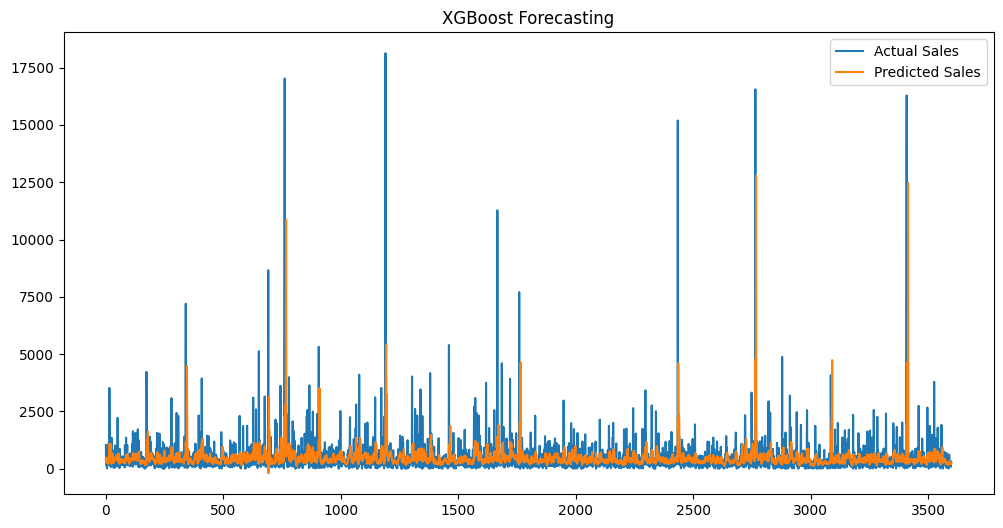

In [78]:
# ============================================================
# STEP 10 — VISUALIZE PREDICTIONS
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    predictions,
    label='Predicted Sales'
)

plt.legend()

plt.title('XGBoost Forecasting')

plt.show()